# Detecția anomaliilor IoT — ECOD
**Referință:** Li et al., *ECOD: Unsupervised Outlier Detection Using Empirical Cumulative Distribution Functions*, IEEE TKDE 2022

```bash
source venv/bin/activate       
pip install -r requirements.txt
```

## Imports și configurare
## Celula 1 — Imports

Folosim **doar infrastructură matematică** — nicio librărie ML.

| Import | Rol |
|--------|-----|
| `numpy` | operații vectorizate pe array-uri numerice |
| `pandas` | citire CSV |
| `matplotlib`, `seaborn` | vizualizare |
| `joblib`, `json` | salvare modele și metadata |

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, json, os, warnings
import time

1. Încarcă CSV-urile
2. Compară median-urile între dispozitive
3. Vizualizează diferențele — argumentul vizual pentru per-device profiling

In [51]:
DATA_DIR  = 'data/normal'
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE_FILES = {
    'gateway'      : f'{DATA_DIR}/gateway_normal.csv',
    'iot_sensor'   : f'{DATA_DIR}/iot_sensor_normal.csv',
    'auth_server'  : f'{DATA_DIR}/auth_server_normal.csv',
    'web_server'   : f'{DATA_DIR}/web_server_normal.csv',
    'smart_camera' : f'{DATA_DIR}/smart_camera_normal.csv',
    'smart_plug'   : f'{DATA_DIR}/smart_plug_normal.csv',
}

# Features numerice — intrarea X a algoritmului
# Excludem: src_ip, dst_ip, src_port, dst_port, protocol, device_type, label
FEATURE_COLS = [
    # FORWARD (initiator → responder)
    'fwd_total_packets', 'fwd_total_bytes',
    'fwd_avg_pkt_size', 'fwd_std_pkt_size', 'fwd_min_pkt_size', 'fwd_max_pkt_size',
    'fwd_avg_iat', 'fwd_std_iat',
    'fwd_syn_count', 'fwd_ack_count', 'fwd_fin_count', 'fwd_rst_count', 'fwd_psh_count',
    # REVERSE (responder → initiator)
    'rev_total_packets', 'rev_total_bytes',
    'rev_avg_pkt_size', 'rev_std_pkt_size', 'rev_min_pkt_size', 'rev_max_pkt_size',
    'rev_avg_iat', 'rev_std_iat',
    'rev_syn_count', 'rev_ack_count', 'rev_fin_count', 'rev_rst_count', 'rev_psh_count',
    # TOTALE și DURATĂ
    'flow_duration', 'total_packets', 'total_bytes',
    'fwd_rev_packet_ratio', 'fwd_rev_byte_ratio',
    # GRAPH FEATURES
    'unique_dst_ips', 'unique_dst_ports', 'connection_degree', 'dst_entropy',
    # DERIVED FEATURES
    'is_standard_port', 'is_internal_only', 'is_night_traffic', 'is_known_pair',
]
#excludem src_ip, dst_ip, src_port, dst_port - nu sunt valori numerice cu sens matematic pt ECDF

In [52]:
def incarca_dispozitiv(path, feature_cols):
    df = pd.read_csv(path)

    # Excludem ICMP/ARP și fluxuri de 1 pachet din antrenare
    # Motivație: aceste fluxuri nu reprezintă comportament aplicativ real
    # și distorsionează modelul — toate atacurile produc 2+ pachete
    if 'src_port' in df.columns and 'dst_port' in df.columns:
        df = df[~((df['src_port'] == 0) & (df['dst_port'] == 0))]
    if 'total_packets' in df.columns:
        inainte = len(df)
        df = df[df['total_packets'] > 1]
        print(f"  {os.path.basename(path)}: {inainte:,} → {len(df):,} fluxuri după filtrare")

    cols_ok = [c for c in feature_cols if c in df.columns] #coloanele disponibile din cele cerute
    cols_lipsa = [c for c in feature_cols if c not in df.columns] # eventuale coloane care pot lipsi in anumite cazuri
    if cols_lipsa:
        print(f'lipsa: {cols_lipsa}')

    X = df[cols_ok].fillna(0).clip(lower=0).values.astype(np.float64) #completam Nan cu 0, valorile negatuve cu 0 si converim la float64 pt ca avem de calculat logaritmi si medii (avem nevoie de precizie zecimala)

    return X, df, cols_ok #returnam matricea de features(n_fluxuri,n_features), dataframe-ul original si lista de coloane folosite


dispozitive = {}

print(f'{"Dispozitiv":15s} {"Fluxuri":>10s} {"Features":>10s}')
print('  ' + '─' * 38)

for device, path in DEVICE_FILES.items():
    if not os.path.exists(path):
        print(f'{device} — skip')
        continue
    X, df, cols = incarca_dispozitiv(path, FEATURE_COLS)
    #LISTA DE TUPLE CU (X,df,cols) PT. FIECARE DISPOZITIV 
    dispozitive[device] = (X, df, cols) #
    #DE ACUM LUCRAM PE ACEASTA VARIABILA, 'dispozitive'
    print(f'{device:15s} {X.shape[0]:>10,} {X.shape[1]:>10}')

Dispozitiv         Fluxuri   Features
  ──────────────────────────────────────
  gateway_normal.csv: 162,871 → 75,454 fluxuri după filtrare
gateway             75,454         39
  iot_sensor_normal.csv: 9,939 → 6,626 fluxuri după filtrare
iot_sensor           6,626         39
  auth_server_normal.csv: 2,178 → 1,260 fluxuri după filtrare
auth_server          1,260         39
  web_server_normal.csv: 119,538 → 39,844 fluxuri după filtrare
web_server          39,844         39
  smart_camera_normal.csv: 9,538 → 6,136 fluxuri după filtrare
smart_camera         6,136         39
  smart_plug_normal.csv: 3,327 → 2,218 fluxuri după filtrare
smart_plug           2,218         39


In [53]:
features_cmp = ['total_packets', 'fwd_avg_iat', 'unique_dst_ports']
#alegem 3 features reprezentative
#total_packets - volumul unui flux (fwd+rev) - cel mai direct indicator de activitate
#fwd_avg_iat — inter-arrival time forward, ritmul pachetelor initiator→responder
#unique_dst_ports - cate porturi destinatie unice a contactat initiatorul

header = f'{"Feature":22s}'
for d in dispozitive:
    header += f'{d:>18s}'
print(header)
print('  ' + '─' * (22 + 18 * len(dispozitive)))

for feat in features_cmp:
    linie = f'{feat:22s}'
    for device, (X, df, cols) in dispozitive.items():
        if feat in cols:
            med = np.median(X[:, cols.index(feat)]) #calculam mediana pentru ca media poate fi distorsionata de outlieri, iar mediana ne da o idee mai clara despre distributia centrala a datelor
            linie += f'{med:>18.3f}'
        else:
            linie += f'{"N/A":>18s}'
    print(linie)
    
    

Feature                          gateway        iot_sensor       auth_server        web_server      smart_camera        smart_plug
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
total_packets                      8.000             5.500            37.000             8.000             8.000             5.500
fwd_avg_iat                        0.000             0.000             0.007             0.000             0.000             0.000
unique_dst_ports                  17.000             1.500             2.000             2.000             2.000             1.000


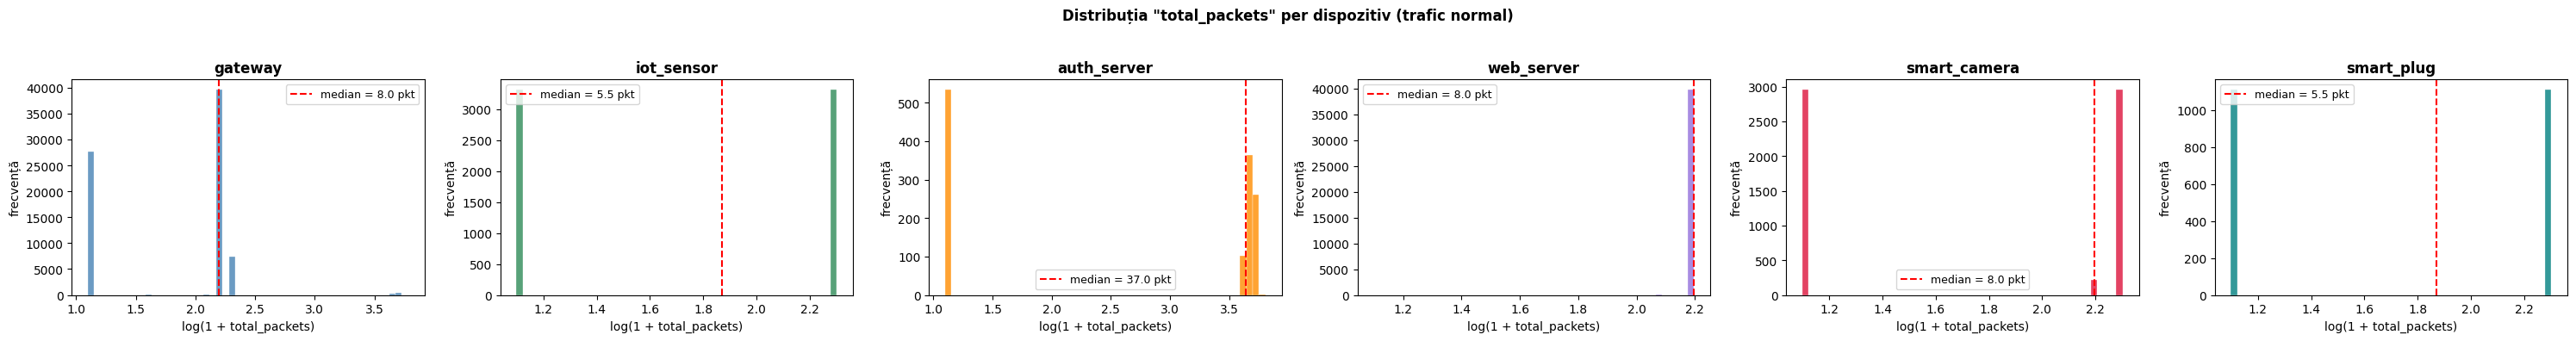

In [54]:
feat_viz = 'total_packets' #alegem total_packets pentru vizualizare
n_dev = len(dispozitive) 
culori = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'crimson', 'teal']

fig, axes = plt.subplots(1, n_dev, figsize=(5 * n_dev, 4)) #creaza o figura cu 1 rand si n_dev coloane de grafice
#20 de unitati de latime si 4 inaltime 
if n_dev == 1:
    axes = [axes]

for ax, (device, (X, df, cols)), culoare in zip(axes, dispozitive.items(), culori):
    if feat_viz not in cols: #daca nu gasim coloana alocata in datele unui anumit dispozitiv, trecem la urmatorul disp
        ax.set_visible(False)
        continue

    vals = X[:, cols.index(feat_viz)] #extragem coloana

    # log1p — necesar pentru vizibilitate (datele de retea sunt skewate puternic)
    ax.hist(np.log1p(vals), bins=50, color=culoare, alpha=0.8, edgecolor='white', linewidth=0.3) #desenam histograma pe np.log1(vals)

    med = np.median(vals) #calculam median-ul pe valorile originale, dar afisam pe scala logaritmica
    #linia rosie verticala = centrul distributiei normale pt. acel dispozitiv
    ax.axvline(np.log1p(med), color='red', lw=1.5, ls='--',label=f'median = {med:.1f} pkt')

    ax.set_title(device, fontweight='bold')
    ax.set_xlabel('log(1 + total_packets)')
    ax.set_ylabel('frecvență')
    ax.legend(fontsize=9)

fig.suptitle(
    f'Distribuția "{feat_viz}" per dispozitiv (trafic normal)\n',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()
#linia rosie marcheaza median-ul pe scara logaritmica - centru distributiei normale pt acel dispozitiv

---
## Celula 3 — Implementare  ECDF și Skewness

Implementăm trei funcții care corespund direct textului matematic din paper:

| Funcție | Ecuație în paper | Ce calculează |
|---------|-----------------|---------------|
| `ecdf_stanga(z, X_train)` | Ecuația (1) | Proporția fluxurilor cu valoare ≤ z |
| `ecdf_dreapta(z, X_train)` | Ecuația (2) | Proporția fluxurilor cu valoare ≥ z |
| `skewness_manual(x)` | Secțiunea 3.2.2 | Asimetria distribuției unui feature |


In [55]:
# ═══════════════════════════════════════════════════════════════════
# ECDF stanga
#
#   F̂_left(z) = (1/n) * Σᵢ 1{Xᵢ ≤ z}    pentru z ∈ ℝ
#
# Unde:
#   n = numărul de fluxuri de antrenare
#   1{Xᵢ ≤ z} = 1 dacă Xᵢ ≤ z, altfel 0  
#   z = valoarea pe care o evaluăm
#
# Interpretare: ce proporție din fluxurile normale aveau valoare ≤ z?
# Detectează valori MICI anormale (coada stângă).
# ═══════════════════════════════════════════════════════════════════
def ecdf_stanga(z, X_train_col):
    n = len(X_train_col)
    # (1/n) * Σ 1{Xᵢ ≤ z}
    return np.mean(X_train_col <= z) #media unui array de 1 si 0; cat % din pachete au val. unei coloane < z


# ═══════════════════════════════════════════════════════════════════
# ECDF dreapta
#
#   F̂_right(z) = (1/n) * Σᵢ 1{Xᵢ ≥ z}    pentru z ∈ ℝ
#
# Paper-ul explică de ce definim separat ECDF dreapta în loc să
# folosim 1 - F̂_left(z): există o asimetrie la egalitate
# (1 - F̂_left folosește inegalitate strictă, F̂_right nu).
#
# Interpretare: ce proporție din fluxurile normale aveau valoare ≥ z?
# Detectează valori MARI anormale (coada dreaptă).
# ═══════════════════════════════════════════════════════════════════
def ecdf_dreapta(z, X_train_col):
    n = len(X_train_col)
    # (1/n) * Σ 1{Xᵢ ≥ z}
    return np.mean(X_train_col >= z)

# F_left(z) numara Xi<=z, iar 1-F_left(z) numara Xi>z, deci avem nevoie de F_right pentru a numara Xi>=z

In [56]:
# ═══════════════════════════════════════════════════════════════════
# FORMULA SKEWNESS - asimetria distributiei
#
#         (1/n) * Σᵢ (Xᵢ - X̄)³
#   γ = ─────────────────────────────
#         [(1/(n-1)) * Σᵢ (Xᵢ - X̄)²]^(3/2)
#
# Unde X̄ = (1/n) * Σᵢ Xᵢ  (media aritmetică)
# - ridicam numarator la putearea a 3-a pt a pastra semnul
# - numitorul normalizeaza rezultatul fata de scara datelor
# - impartim la 1.5 si obtinem un numar admimensional, comparabil intre feature-uri cu scale diferite
#
# Interpretare:
#   γ < 0 -> coada lunga la stanga
#            -> ECOD va folosi F̂_left pentru acest feature
#   γ ≥ 0 -> coada lunga la dreapta
#            -> ECOD va folosi F̂_right pentru acest feature
# ═══════════════════════════════════════════════════════════════════
def skewness_manual(x):
    n = len(x)
    x_  = np.mean(x)           
    dev = x - x_               
    # Numaratorul: (1/n) * Σ (Xᵢ - X̄)³
    numarator = np.mean(dev ** 3)

    # Numitorul: [(1/(n-1)) * Σ (Xᵢ - X̄)²]^(3/2)
    # (1/(n-1)) este corectia Bessel
    varianta_esantion = np.sum(dev ** 2) / (n - 1)
    numitor = varianta_esantion ** 1.5
    if numitor == 0:
        return 0.0

    return numarator / numitor
#

In [57]:
# SKEWNESS pe toate features, pentru toate dispozitivele
# skewness_per_dispozitiv[device] = array de lungime d (nr. features)
# skewness_per_dispozitiv[device][j] = γⱼ pentru feature-ul j
skewness_per_dispozitiv = {}

for device, (X, _, cols) in dispozitive.items():
    n, d = X.shape
    gamma = np.zeros(d)    # vector de d valori, cate una per feature 
    for j in range(d):     # pentru fiecare dimensiune j
        gamma[j] = skewness_manual(X[:, j]) #pt fiecare feature calculam skwwness

    skewness_per_dispozitiv[device] = gamma #pt fiecare dispozitiv





device_ex = 'gateway'
gamma_ex = skewness_per_dispozitiv[device_ex]
cols_ex = dispozitive[device_ex][2]

print(f'  [{device_ex}]')
print(f'  {"Feature":25s} {"γ":>10s}  Decizie ECOD')
print('  ' + '─' * 55)

for feat, g in zip(cols_ex, gamma_ex):
    decizie = '-> coadă dreaptă ↑' if g >= 0 else '-> coadă stângă ↓'
    print(f'  {feat:25s} {g:>10.3f}  {decizie}')


  [gateway]
  Feature                            γ  Decizie ECOD
  ───────────────────────────────────────────────────────
  fwd_total_packets              2.311  -> coadă dreaptă ↑
  fwd_total_bytes                7.571  -> coadă dreaptă ↑
  fwd_avg_pkt_size               7.602  -> coadă dreaptă ↑
  fwd_std_pkt_size               7.354  -> coadă dreaptă ↑
  fwd_min_pkt_size               4.874  -> coadă dreaptă ↑
  fwd_max_pkt_size               9.416  -> coadă dreaptă ↑
  fwd_avg_iat                   79.674  -> coadă dreaptă ↑
  fwd_std_iat                  274.486  -> coadă dreaptă ↑
  fwd_syn_count                 -0.551  -> coadă stângă ↓
  fwd_ack_count                  2.408  -> coadă dreaptă ↑
  fwd_fin_count                 -1.095  -> coadă stângă ↓
  fwd_rst_count                  0.000  -> coadă dreaptă ↑
  fwd_psh_count                  5.554  -> coadă dreaptă ↑
  rev_total_packets              5.348  -> coadă dreaptă ↑
  rev_total_bytes                1.725  -> coadă drea

Text(0, 0.5, '−log(F̂_right(z))')

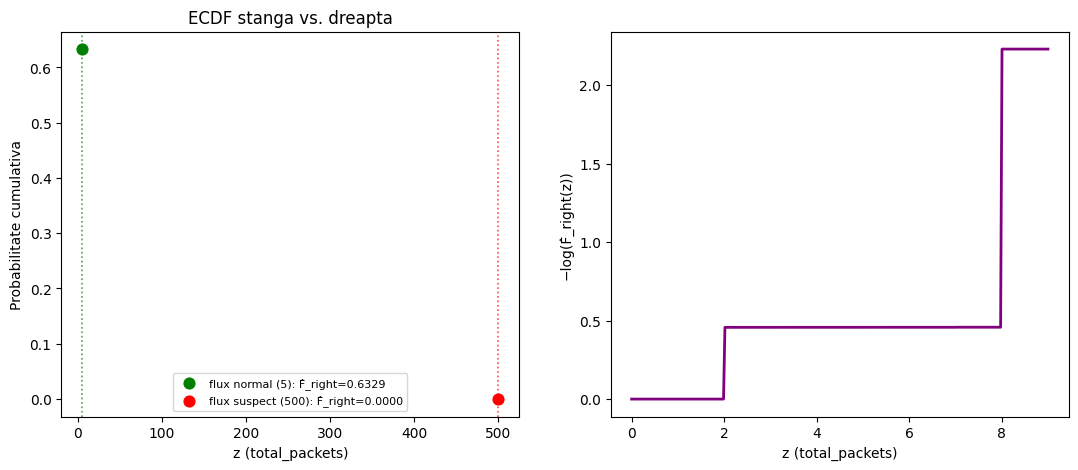

In [58]:
X_gw, _, cols_gw = dispozitive['gateway']
col_pkt = X_gw[:, cols_gw.index('total_packets')]

p99 = np.percentile(col_pkt, 99)
z_grid = np.linspace(0, p99, 300)

f_left  = np.array([ecdf_stanga(z, col_pkt)  for z in z_grid])
f_right = np.array([ecdf_dreapta(z, col_pkt) for z in z_grid])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for z_ex, culoare, label in [(5, 'green', 'flux normal (5)'), (500, 'red', 'flux suspect (500)')]:
    ax1.axvline(z_ex, color=culoare, ls=':', lw=1.2, alpha=0.7)
    p_r = ecdf_dreapta(z_ex, col_pkt)
    ax1.scatter([z_ex], [p_r], color=culoare, zorder=5, s=60,label=f'{label}: F̂_right={p_r:.4f}')

ax1.set_xlabel('z (total_packets)')
ax1.set_ylabel('Probabilitate cumulativa')
ax1.set_title('ECDF stanga vs. dreapta')
ax1.legend(fontsize=8)


EPSILON = 1e-10                              # evităm log(0)
f_right_safe = np.maximum(f_right, EPSILON)
scor_partial = -np.log(f_right_safe)             # -log(F̂_right(z))

ax2.plot(z_grid, scor_partial, color='purple', lw=2)
ax2.set_xlabel('z (total_packets)')
ax2.set_ylabel('−log(F̂_right(z))')


##  Scorurile O_left, O_right, O_auto, O_final
Logica e în spațiul **log-probabilitate negativă**:
- probabilitate mică în coadă -> `-log(prob mică)` = număr **mare**
- scor final mare = flux **suspect**

| Ecuație | Formulă | Ce face |
|---------|---------|--------|
| (4) | `O_left  = -Σⱼ log(F̂_left(Xⱼ))`  | scor dacă toate features ar fi în coada stângă |
| (5) | `O_right = -Σⱼ log(F̂_right(Xⱼ))` | scor dacă toate features ar fi în coada dreaptă |
| (6) | `O_auto  = -Σⱼ log(F̂_auto(Xⱼ))` | scor cu coada aleasă automat prin skewness |
| (6) | `O_final = max(O_left, O_right, O_auto)` | cel mai extrem din cele 3 câștigă |

In [59]:
def antreneaza_ecod(X_train, feature_names):
    n, d = X_train.shape
    gamma = np.zeros(d)
    for j in range(d):
        gamma[j] = skewness_manual(X_train[:, j])

    model = {
        'X_train'      : X_train,       # datele de antrenare — necesare pentru ECDF
        'gamma'        : gamma,          # skewness per feature — decide coada
        'feature_names': feature_names,  # numele features
        'n'            : n,              # numar fluxuri antrenare
        'd'            : d,              # numar features
    }
    return model
#asta e toata antrenarea - fara epoci, fara optimizare

In [60]:
EPSILON = 1e-10 #

def calculeaza_scoruri_vectorizat(X_eval, model):
    X_train = model['X_train']  
    gamma = model['gamma']    
    m, d = X_eval.shape
    n = X_train.shape[0]

    termeni_left  = np.zeros((m, d))
    termeni_right = np.zeros((m, d))

    for j in range(d):
        #------------------------calcul vectorizat
        col_train = X_train[:, j]  
        col_eval  = X_eval[:, j]   

        mat_stanga  = col_train[np.newaxis, :] <= col_eval[:, np.newaxis]   
        p_left = mat_stanga.mean(axis=1) #calculam simultan F_left pt. toate cele m fluxuri de evaluat

        mat_dreapta = col_train[np.newaxis, :] >= col_eval[:, np.newaxis]   
        p_right = mat_dreapta.mean(axis=1)   #calculam simultan F_ringt pt. toate cele m fluxuri de evaluat                          
        #------------------------end calcul vectorizat

        #inlocuim orice 0 cu EPSILOR
        p_left  = np.maximum(p_left,  EPSILON)
        p_right = np.maximum(p_right, EPSILON)

        termeni_left[:, j]  = -np.log(p_left) #tranforma probabilitatile in scoruri
        # probabilitate mare (0.9) => -log(0.9) = 0.105 => scor mic, valoare obisnuita
        # probailitate mica (0.001) => -log(0.001) = 6.9 => scor mare, valoare rara
        termeni_right[:, j] = -np.log(p_right) #stocam scorurile pt toate cele m linii [e un feature j]

    O_left  = termeni_left.sum(axis=1)   #suma scorurilor pe toate pele 18 features pe coada din stanga
    O_right = termeni_right.sum(axis=1)   #suma scorurilor po coada din dreapta

    masca_dreapta = (gamma >= 0) #array boolean cu true pt features cu y>=0(coada dreapta) si false pt y<0(coada stanga)        

    #pt fiecare coloana j, daca masca[j]==True valoarea venea din termeni_right[:,j], altfel din termeni_left[:,j]
    termeni_auto  = np.where(masca_dreapta,                 
                             termeni_right,
                             termeni_left)
    
    O_auto = termeni_auto.sum(axis=1) #suma pe featurea

    O_final = np.maximum(np.maximum(O_left, O_right), O_auto)  #element cu element, luam maximul dintre O_right, O_left si apoi dintre rez. si O_auto
    
    return O_final, termeni_auto

In [61]:

modele = {}

for device, (X_train, _, cols) in dispozitive.items():
    t0 = time.time()
    model = antreneaza_ecod(X_train, cols)
    elapsed = time.time() - t0

    modele[device] = model
    print(f'{device:15s} {X_train.shape[0]:>10,} {X_train.shape[1]:>10} {elapsed:>7.2f}s') #parcurgem cele 4 dispozitive si antream 

print()
print('Skewness gateway (primele 5 features):')
m_gw = modele['gateway']
cols_5 = m_gw['feature_names'][:5]
gam_5 = m_gw['gamma'][:5]
for c, g in zip(cols_5, gam_5):
    coada = 'dreaptă ↑' if g >= 0 else 'stângă ↓'
    print(f'{c:25s}  γ = {g:8.3f}  -> coadă {coada}')

gateway             75,454         39    0.02s
iot_sensor           6,626         39    0.00s
auth_server          1,260         39    0.00s
web_server          39,844         39    0.01s
smart_camera         6,136         39    0.00s
smart_plug           2,218         39    0.00s

Skewness gateway (primele 5 features):
fwd_total_packets          γ =    2.311  -> coadă dreaptă ↑
fwd_total_bytes            γ =    7.571  -> coadă dreaptă ↑
fwd_avg_pkt_size           γ =    7.602  -> coadă dreaptă ↑
fwd_std_pkt_size           γ =    7.354  -> coadă dreaptă ↑
fwd_min_pkt_size           γ =    4.874  -> coadă dreaptă ↑


In [62]:
def calculeaza_scoruri_batched(X_eval, model, batch_size=1000):
    m = X_eval.shape[0]
    O_final_all = np.zeros(m)
    contrib_all = np.zeros((m, X_eval.shape[1]))

    for start in range(0, m, batch_size):
        end = min(start + batch_size, m)
        batch = X_eval[start:end]

        O_final_batch, contrib_batch = calculeaza_scoruri_vectorizat(batch, model)
        O_final_all[start:end] = O_final_batch
        contrib_all[start:end] = contrib_batch

    return O_final_all, contrib_all


scoruri_antrenare = {}  

print(f'{"Dispozitiv":15s} {"Fluxuri":>10s} {"Timp":>8s} ' f'{"Scor min":>10s} {"Median":>10s} {"Scor max":>10s}')
print('  ' + '─' * 70)

for device, model in modele.items():
    X_train = model['X_train']
    t0 = time.time()

    scoruri, _ = calculeaza_scoruri_batched(X_train, model, batch_size=500)
    elapsed = time.time() - t0

    scoruri_antrenare[device] = scoruri

    print(f'{device:15s} {len(scoruri):>10,} {elapsed:>7.1f}s '
          f'{scoruri.min():>10.2f} {np.median(scoruri):>10.2f} {scoruri.max():>10.2f}')
    

# from scipy import stats
# print(stats.skew(X_gw[:, 0]))           # scipy
# print(skewness_manual(X_gw[:, 0]))      # al meu


Dispozitiv         Fluxuri     Timp   Scor min     Median   Scor max
  ──────────────────────────────────────────────────────────────────────
gateway             75,454   268.4s      12.53      27.47     173.82
iot_sensor           6,626     2.0s      17.94      21.92      60.39
auth_server          1,260     0.1s      18.85      24.78     101.68
web_server          39,844    74.8s       4.12       7.88     227.68
smart_camera         6,136     1.7s      17.65      23.50      84.19
smart_plug           2,218     0.3s      17.97      21.29      54.26


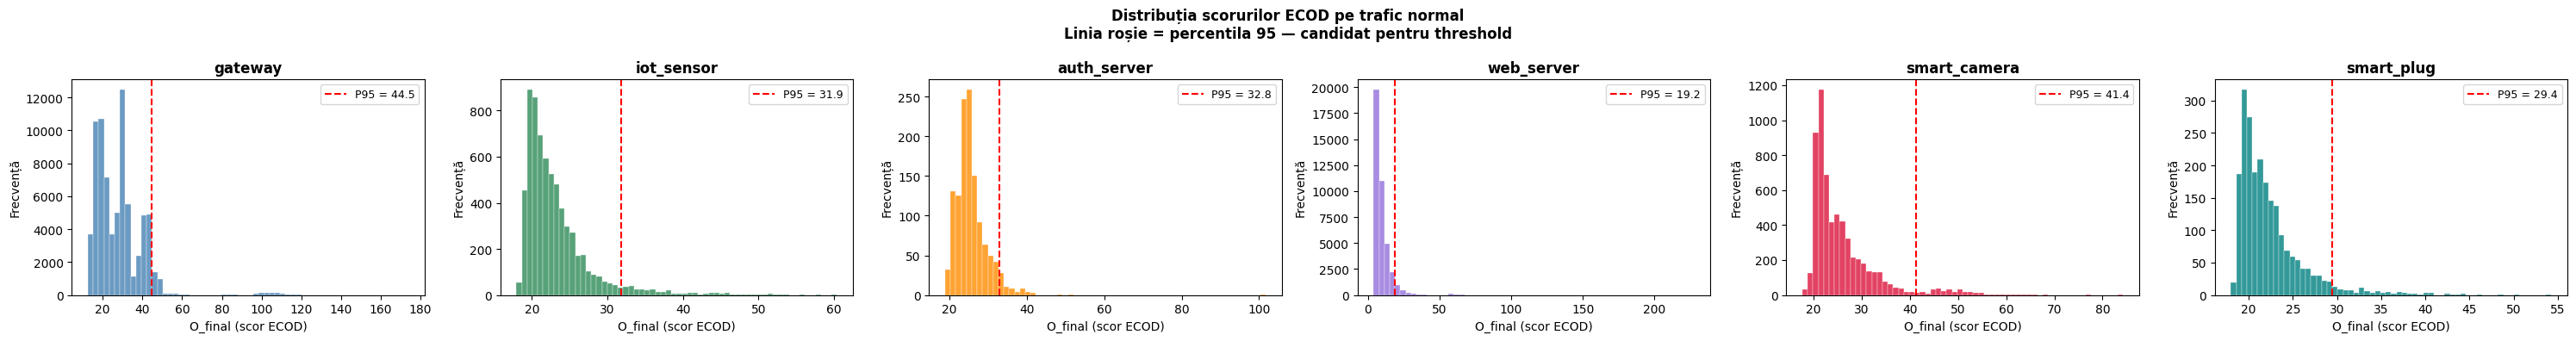

In [63]:
n_dev  = len(scoruri_antrenare)
culori = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'crimson', 'teal']

#histograma scorurilor pe trafic normal per dispozitiv
fig, axes = plt.subplots(1, n_dev, figsize=(5 * n_dev, 4))
if n_dev == 1:
    axes = [axes]

for ax, (device, scoruri), culoare in zip(axes, scoruri_antrenare.items(), culori):
    ax.hist(scoruri, bins=60, color=culoare, alpha=0.8,
            edgecolor='white', linewidth=0.3)

    p95 = np.percentile(scoruri, 95)
    ax.axvline(p95, color='red', lw=1.5, ls='--',label=f'P95 = {p95:.1f}') #valoarea sub care cad 95% din scoruri

    ax.set_title(device, fontweight='bold')
    ax.set_xlabel('O_final (scor ECOD)')
    ax.set_ylabel('Frecvență')
    ax.legend(fontsize=9)

fig.suptitle(
    'Distribuția scorurilor ECOD pe trafic normal\n'
    'Linia roșie = percentila 95 — candidat pentru threshold',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig4_distributie_scoruri_normale.png', bbox_inches='tight')
plt.show()


## Celula 5 — Calibrare threshold si salvare modele pe disc

**Ce se intampla:**
1. Calculam threshold-ul per dispozitiv din distributia scorurilor normale
2. Salvam modelul antrenat ca fisier joblib
3. Salvam metadata ca JSON — threshold, feature names, statistici

In [64]:
PERCENTILA = 99 

thresholds = {} #stocam  threshold-ul per dispozitiv
print(f'{"Dispozitiv":15s} {"Threshold":>12s} {"FPR efectiv":>14s}')
print('  ' + '-' * 44)

for device, scoruri in scoruri_antrenare.items():

    # Calculam percentila 95 din scorurile de antrenare
    thr = np.percentile(scoruri, PERCENTILA) #returnam valoarea sub care cad 95% din scorurile normale 
    thresholds[device] = thr
    fpr = (scoruri > thr).mean() * 100 #procentul de fluxuri normale care au scor peste threshold (fals pozitive)

    print(f'{device:15s} {thr:>12.3f} {fpr:>13.1f}%')

print()
print('Flux nou cu scor > threshold -> investigat ca anomalie')
print('Flux nou cu scor ≤ threshold -> tratat ca normal')


Dispozitiv         Threshold    FPR efectiv
  --------------------------------------------
gateway               61.787           1.0%
iot_sensor            43.359           1.0%
auth_server           38.910           1.0%
web_server            30.557           1.0%
smart_camera          52.985           1.0%
smart_plug            37.616           1.0%

Flux nou cu scor > threshold -> investigat ca anomalie
Flux nou cu scor ≤ threshold -> tratat ca normal


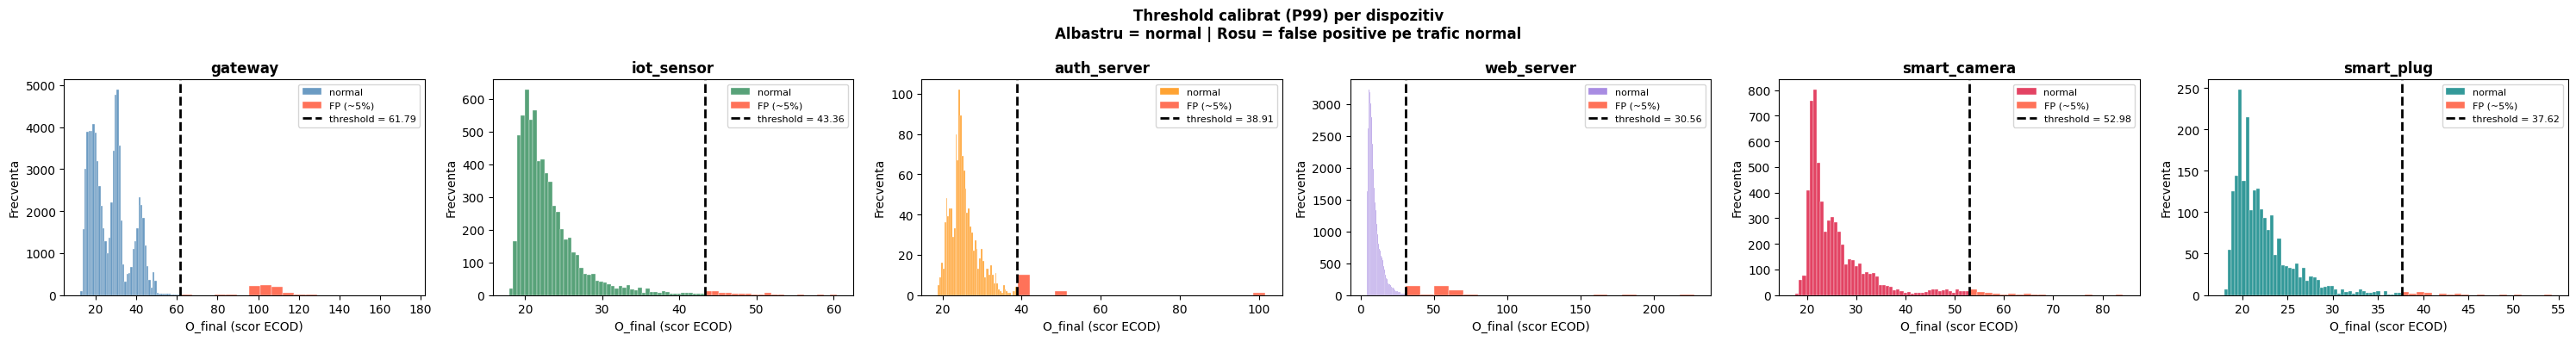

In [65]:
n_dev  = len(scoruri_antrenare)
culori = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'crimson', 'teal']

fig, axes = plt.subplots(1, n_dev, figsize=(5 * n_dev, 4))
if n_dev == 1:
    axes = [axes]

for ax, (device, scoruri), culoare in zip(axes, scoruri_antrenare.items(), culori):
    thr = thresholds[device]

    # Scoruri sub threshold = normal (culoarea dispozitivului)
    ax.hist(scoruri[scoruri <= thr], bins=50, color=culoare, alpha=0.8, edgecolor='white', linewidth=0.3, label='normal')

    # Scoruri peste threshold = false positive pe date normale (rosu)
    ax.hist(scoruri[scoruri > thr], bins=20, color='tomato', alpha=0.9, edgecolor='white', linewidth=0.3, label='FP (~5%)')

    ax.axvline(thr, color='black', lw=2, ls='--', label=f'threshold = {thr:.2f}')

    ax.set_title(device, fontweight='bold')
    ax.set_xlabel('O_final (scor ECOD)')
    ax.set_ylabel('Frecventa')
    ax.legend(fontsize=8)

fig.suptitle(
    f'Threshold calibrat (P{PERCENTILA}) per dispozitiv\n'
    'Albastru = normal | Rosu = false positive pe trafic normal',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig5_threshold_calibrat.png', bbox_inches='tight')
plt.show()

In [72]:
# Percentila 99.9 pentru dispozitive cu multe date
for device in ['gateway', 'web_server']:
    scoruri = scoruri_antrenare[device]
    thr_nou = np.percentile(scoruri, 99.9)
    thresholds[device] = thr_nou
    print(f"{device:15s}  p99.9={thr_nou:.3f}")

# Max*1.15 pentru dispozitive cu puține date
for device in ['smart_plug', 'smart_camera']:
    scoruri = scoruri_antrenare[device]
    thr_nou = scoruri.max() * 1.15
    thresholds[device] = thr_nou
    print(f"{device:15s}  max={scoruri.max():.3f}  →  threshold={thr_nou:.3f}")

# Buffer mare pentru iot_sensor
scoruri_iot = scoruri_antrenare['iot_sensor']
thresholds['iot_sensor'] = scoruri_iot.max() * 2.0
print(f"iot_sensor  max={scoruri_iot.max():.3f} → threshold={scoruri_iot.max()*2.0:.3f}")

gateway          p99.9=112.091
web_server       p99.9=65.707
smart_plug       max=54.263  →  threshold=62.402
smart_camera     max=84.192  →  threshold=96.821
iot_sensor  max=60.392 → threshold=120.784


In [73]:
# ────────────────────────────────SALVARE MODELE─────────────────────────────
# ecod_model.joblib  -> modelul complet (X_train + gamma) necesar pentru ECDF la inferenta
# metadata.json -> threshold, feature names

def numpy_to_python(obj):
    if isinstance(obj, np.integer):  return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray):  return obj.tolist()
    if isinstance(obj, dict): return {k: numpy_to_python(v) for k, v in obj.items()}
    if isinstance(obj, list): return [numpy_to_python(v) for v in obj]
    return obj


for device, model in modele.items(): #parcurgem fiecare dispozitv si creeam un subdirector in MODEL_DIR pentru a stoca modelul si metadatele aferente
    device_dir = os.path.join(MODEL_DIR, device)
    os.makedirs(device_dir, exist_ok=True)

    scoruri = scoruri_antrenare[device]
    thr = thresholds[device]
    X_train = model['X_train']

    #salvam modelul complet cu joblib pt ca joblib e optimizat pt numpy arrays mari
    #comprima si serializeaza eficient matricea X_train de 94.851 x 18
    model_path = os.path.join(device_dir, 'ecod_model.joblib')
    joblib.dump(model, model_path)

    #metadate JSON
    metadata = {
        'device'        : device,
        'algorithm'     : 'ECOD',
        'threshold'     : float(thr), #folosit mai tarziu pt a compara scorul unui flux nou cu el
        'threshold_pct' : PERCENTILA,
        'fpr_target_pct': 100 - PERCENTILA,
        'feature_names' : model['feature_names'],
        'n_train'       : int(model['n']),
        'd_features'    : int(model['d']),
        'gamma'         : model['gamma'].tolist(),
        'train_stats': {
            'mean'  : numpy_to_python(X_train.mean(axis=0)),
            'std'   : numpy_to_python(X_train.std(axis=0)),
            'median': numpy_to_python(np.median(X_train, axis=0)),
            'p95'   : numpy_to_python(np.percentile(X_train, 95, axis=0)),
            'p99'   : numpy_to_python(np.percentile(X_train, 99, axis=0)),
        },
        'score_stats': {
            'min'   : float(scoruri.min()),
            'median': float(np.median(scoruri)),
            'p95'   : float(np.percentile(scoruri, 95)),
            'p99'   : float(np.percentile(scoruri, 99)),
            'max'   : float(scoruri.max()),
        },
    }

    meta_path = os.path.join(device_dir, 'metadata.json')
    with open(meta_path, 'w') as f:
        json.dump(numpy_to_python(metadata), f, indent=2)

    print(f'{device:15s}  threshold={thr:.3f}  ->  {device_dir}/')

# Registry global — fisier JSON care listeaza calea tuturor modelelor 
registry = {
    device: {
        'model'   : os.path.join(MODEL_DIR, device, 'ecod_model.joblib'),
        'metadata': os.path.join(MODEL_DIR, device, 'metadata.json'),
    }
    for device in modele
}
reg_path = os.path.join(MODEL_DIR, 'registry.json')
with open(reg_path, 'w') as f:
    json.dump(registry, f, indent=2)

gateway          threshold=112.091  ->  models/gateway/
iot_sensor       threshold=120.784  ->  models/iot_sensor/
auth_server      threshold=38.910  ->  models/auth_server/
web_server       threshold=65.707  ->  models/web_server/
smart_camera     threshold=96.821  ->  models/smart_camera/
smart_plug       threshold=62.402  ->  models/smart_plug/


In [68]:
# ────────────────────────────SANITY CHECK─────────────────────────────────────
#
# Incarcam modelul de pe disc si verificam ca scorurile
# sunt identice cu cele calculate anterior.
# Daca difera -> ceva a mers gresit la salvare.
# ─────────────────────────────────────────────────────────────────

for device in modele:
    model_path = os.path.join(MODEL_DIR, device, 'ecod_model.joblib')
    model_disc = joblib.load(model_path)

    meta_path = os.path.join(MODEL_DIR, device, 'metadata.json')
    with open(meta_path) as f:
        meta = json.load(f)

    # Calculam scorurile pentru primele 5 fluxuri din modelul incarcat
    X_test = model_disc['X_train'][:5]
    scoruri_test, _ = calculeaza_scoruri_batched(X_test, model_disc)
    thr = meta['threshold']

    # Comparam cu scorurile calculate anterior in sesiunea curenta
    scoruri_orig = scoruri_antrenare[device][:5]
    identice = np.allclose(scoruri_test, scoruri_orig, rtol=1e-5)

    status = 'OK' if identice else 'EROARE'
    print(f'{device:15s}  threshold={thr:.3f}  scoruri identice={identice}  [{status}]')

# print()
# print('Structura finala a folderului models/:')
# for root, dirs, files in os.walk(MODEL_DIR):
#     level  = root.replace(MODEL_DIR, '').count(os.sep)
#     indent = '  ' * level
#     print(f'{indent}{os.path.basename(root)}/')
#     for fname in sorted(files):
#         print(f'{indent}  {fname}')


gateway          threshold=61.787  scoruri identice=True  [OK]
iot_sensor       threshold=120.784  scoruri identice=True  [OK]
auth_server      threshold=38.910  scoruri identice=True  [OK]
web_server       threshold=30.557  scoruri identice=True  [OK]
smart_camera     threshold=96.821  scoruri identice=True  [OK]
smart_plug       threshold=62.402  scoruri identice=True  [OK]


In [69]:
# ─────────────────────────────────────────────────────────────────
# VERIFICARE IMPLEMENTARE MANUALĂ vs pyod.ECOD oficial

from pyod.models.ecod import ECOD
from scipy import stats

print("Verificare implementare manuală vs pyod.ECOD\n")
print(f"{'Dispozitiv':15s} {'Corel.Pearson':>15s} {'Skewness manual vs scipy':>25s}")
print("-" * 58)

for device, (X_train, _, cols) in dispozitive.items():
    # ── pyod ECOD oficial ─────────────────────────────────────────
    clf = ECOD()
    clf.fit(X_train)
    scoruri_pyod = clf.decision_scores_

    scoruri_manual, _ = calculeaza_scoruri_batched(X_train, modele[device])

    corel, _ = stats.pearsonr(scoruri_manual, scoruri_pyod)

    gamma_manual = modele[device]['gamma'][0]  # total_packets
    gamma_scipy  = stats.skew(X_train[:, 0])

    print(f"  {device:15s} {corel:>15.4f}   γ manual={gamma_manual:.3f} vs scipy={gamma_scipy:.3f}")

print()
print("Interpretare:")
print("  Corelatie > 0.95 → implementarea manuală e corectă")
print("  Corelatie < 0.90 → există diferențe semnificative")

Verificare implementare manuală vs pyod.ECOD

Dispozitiv        Corel.Pearson  Skewness manual vs scipy
----------------------------------------------------------


/opt/homebrew/lib/python3.11/site-packages/pyod/models/ecod.py:23: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.nan_to_num(skew_sp(X, axis=axis))


  gateway                  0.9802   γ manual=2.311 vs scipy=2.311


/opt/homebrew/lib/python3.11/site-packages/pyod/models/ecod.py:23: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.nan_to_num(skew_sp(X, axis=axis))


  iot_sensor               0.9878   γ manual=0.000 vs scipy=0.000
  auth_server              0.9742   γ manual=-0.308 vs scipy=-0.308


...

  web_server               0.9915   γ manual=-53.737 vs scipy=-53.739


/opt/homebrew/lib/python3.11/site-packages/pyod/models/ecod.py:23: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.nan_to_num(skew_sp(X, axis=axis))


  smart_camera             0.9867   γ manual=-0.050 vs scipy=-0.050


/opt/homebrew/lib/python3.11/site-packages/pyod/models/ecod.py:23: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.nan_to_num(skew_sp(X, axis=axis))


  smart_plug               0.9926   γ manual=0.000 vs scipy=0.000

Interpretare:
  Corelatie > 0.95 → implementarea manuală e corectă
  Corelatie < 0.90 → există diferențe semnificative


In [70]:
import pandas as pd
import numpy as np
import joblib, json

for device in ['iot_sensor', 'web_server']:
    with open(f'models/{device}/metadata.json') as f:
        meta = json.load(f)
    
    print(f"=== {device} ===")
    print(f"  Threshold    : {meta['threshold']:.3f}")
    print(f"  Score median : {meta['score_stats']['median']:.3f}")
    print(f"  Score P99    : {meta['score_stats']['p99']:.3f}")
    print(f"  Score max    : {meta['score_stats']['max']:.3f}")
    print(f"  Train n      : {meta['n_train']}")
    print()

=== iot_sensor ===
  Threshold    : 120.784
  Score median : 21.923
  Score P99    : 43.359
  Score max    : 60.392
  Train n      : 6626

=== web_server ===
  Threshold    : 30.557
  Score median : 7.876
  Score P99    : 30.557
  Score max    : 227.676
  Train n      : 39844



In [71]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/normal/auth_server_normal.csv')
df = df[~((df['src_port'] == 0) & (df['dst_port'] == 0))]
df = df[df['total_packets'] > 1]

print("avg_pkt_size pe auth_server:")
#print(f"  min    : {df['avg_pkt_size'].min():.2f}")
#print(f"  median : {df['avg_pkt_size'].median():.2f}")
# print(f"  P95    : {df['avg_pkt_size'].quantile(0.95):.2f}")
# print(f"  P99    : {df['avg_pkt_size'].quantile(0.99):.2f}")
# print(f"  max    : {df['avg_pkt_size'].max():.2f}")
# print(f"  std    : {df['avg_pkt_size'].std():.2f}")
print()
print("Distribuție total_packets pe auth_server:")
print(df['total_packets'].value_counts().sort_index())

avg_pkt_size pe auth_server:

Distribuție total_packets pe auth_server:
total_packets
2     534
37    101
38    103
39    260
40    194
41     67
44      1
Name: count, dtype: int64
